# Actividad: Árboles de regresión -- sobreajuste y poda

Van a usar un **árbol de regresión** (`DecisionTreeRegressor`) para predecir el precio de casas en California, usando el dataset real *California Housing* (~20,000 casas, con ingreso promedio de la zona, edad de las casas, ubicación geográfica, etc.), cargado directamente con `sklearn.datasets.fetch_california_housing` -- la fuente oficial. Se descarga solo (y se guarda en caché) la primera vez que corran la celda de preparación; no necesitan subir ni descargar ningún archivo a mano.

El objetivo no es solo "usar un árbol" — es ver el ejemplo más claro de **sobreajuste** que existe en Machine Learning: un árbol sin restricciones puede memorizar perfectamente el conjunto de entrenamiento y aun así generalizar igual de mal, o peor, que un modelo lineal simple. Después van a controlar ese sobreajuste con las mismas herramientas de "regularización" que ya conocen de otras actividades (curvas de validación, cross-validation para elegir hiperparámetros), aplicadas esta vez a un árbol — incluyendo la **poda (pruning)**.

In [2]:
# ============================================================
# PREPARACIÓN — no modifiquen esta celda
# ============================================================
# Los datos se descargan automáticamente la primera vez que corran esta
# celda, directo desde scikit-learn (no necesitan subir ni descargar nada
# a mano). La primera corrida puede tardar unos segundos mientras se baja
# y se guarda en caché local; las siguientes veces será instantáneo.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

datos = fetch_california_housing(as_frame=True)
df = datos.frame

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]   # precio en cientos de miles de USD

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Filas totales: {len(X)}")
print(f"Entrenamiento: {X_train.shape}   Prueba: {X_test.shape}")
X.describe()

Filas totales: 20640
Entrenamiento: (16512, 8)   Prueba: (4128, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


## Parte A — Un árbol sin restricciones

Ajusten un `DecisionTreeRegressor` con sus parámetros por default (sin limitar profundidad ni nada) y comparen su error en entrenamiento contra su error en prueba.

**Antes de correr la celda:** ¿qué esperarían? Un árbol puede seguir dividiendo hasta que cada hoja tenga una sola observación — ¿qué le pasaría al error de entrenamiento en ese caso?

In [3]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

arbol_completo = DecisionTreeRegressor(random_state=42)
arbol_completo.fit(X_train, y_train)

mse_train = mean_squared_error(y_train, arbol_completo.predict(X_train))
mse_test = mean_squared_error(y_test, arbol_completo.predict(X_test))

print(f"Profundidad real del árbol: {arbol_completo.get_depth()}")
print(f"Número de hojas: {arbol_completo.get_n_leaves()}")
print(f"\nMSE entrenamiento: {mse_train:.5f}")
print(f"MSE prueba:        {mse_test:.5f}")

# Comparación contra un modelo lineal simple, sin ningún ajuste especial
regresion_lineal = LinearRegression().fit(X_train, y_train)
mse_test_lineal = mean_squared_error(y_test, regresion_lineal.predict(X_test))
print(f"\n(referencia) MSE prueba de LinearRegression simple: {mse_test_lineal:.5f}")

Profundidad real del árbol: 34
Número de hojas: 15870

MSE entrenamiento: 0.00000
MSE prueba:        0.50311

(referencia) MSE prueba de LinearRegression simple: 0.55589


**¿Qué observan?** El árbol sin restricciones llega a un MSE de entrenamiento prácticamente en cero — memorizó el conjunto de entrenamiento casi observación por observación (revisen cuántas hojas tiene: probablemente casi tantas como filas de entrenamiento). Pero en el conjunto de prueba, su error es básicamente el mismo (o peor) que el de una regresión lineal simple, sin ningún truco.

Esa es la lección central de esta actividad: **un modelo que "aprende perfecto" el entrenamiento no es necesariamente un buen modelo.** El árbol tiene, en teoría, mucha más capacidad que una regresión lineal para capturar relaciones no lineales — pero sin ningún control, esa capacidad se usa para memorizar ruido, no para encontrar patrones que generalicen.

## Parte B — Controlando la profundidad (`max_depth`)

El hiperparámetro más directo para controlar un árbol es qué tan profundo lo dejas crecer. Construyan una **curva de validación** sobre `max_depth` — el mismo tipo de gráfica que ya hicieron para `n_neighbors` en KNN en tu notebook de learning/validation curves, pero ahora para un árbol.

Usen `validation_curve` de `sklearn.model_selection`, con:
- `param_name="max_depth"`
- `param_range` de 1 a 20
- `cv=5`
- `scoring="neg_mean_squared_error"` (recuerden multiplicar por -1 para obtener MSE positivo)

Grafiquen el MSE de entrenamiento y de validación contra `max_depth`, igual que en tu notebook de KNN.

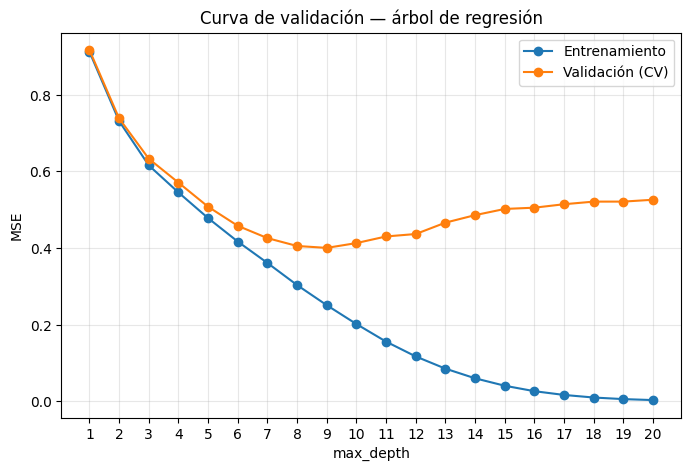

Mejor max_depth: 9  (MSE validación = 0.4007)


In [4]:
param_range = range(1, 21)

train_scores, val_scores = validation_curve(
    DecisionTreeRegressor(random_state=42), X_train, y_train,
    param_name="max_depth", param_range=param_range,
    cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
val_mean   = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_mean, "o-", label="Entrenamiento")
plt.plot(param_range, val_mean,   "o-", label="Validación (CV)")
plt.xlabel("max_depth"); plt.ylabel("MSE"); plt.xticks(param_range)
plt.title("Curva de validación — árbol de regresión")
plt.legend(); plt.grid(alpha=0.3); plt.show()

mejor_depth = param_range[val_mean.argmin()]
print(f"Mejor max_depth: {mejor_depth}  (MSE validación = {val_mean.min():.4f})")


**Para anotar:** ¿en qué valor de `max_depth` empieza a subir otra vez el error de validación, aunque el de entrenamiento siga bajando? Ese es el punto donde el árbol empieza a sobreajustar.

## Parte C — Poda por costo-complejidad (`ccp_alpha`)

`max_depth` es una forma de regularizar un árbol, pero es "toda o nada": aplica el mismo límite a todas las ramas por igual. Existe una forma más fina, la **poda por costo-complejidad** (cost-complexity pruning) — la misma "poda (prunning)" que se menciona en la diapositiva de árboles de decisión. En vez de fijar una profundidad máxima, se penaliza cada hoja adicional con un costo `ccp_alpha`: entre más grande el `alpha`, más ramas se podan, incluso si dejan ramas de profundidades distintas en distintas partes del árbol.

La función `cost_complexity_pruning_path` calcula, para TU árbol y TUS datos, la lista real de valores de `alpha` en los que vale la pena podar una rama:

In [ ]:
# ============================================================
# Ya lista — no modificar
# ============================================================
path = DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(f"Número de valores de alpha en el camino de poda: {len(ccp_alphas)}")
print(f"Rango: {ccp_alphas[0]:.6f} a {ccp_alphas[-1]:.6f}")

# Probar los 14,000+ valores exactos con cross-validation sería lentísimo --
# probamos un subconjunto razonable, espaciado logarítmicamente
alphas_a_probar = np.logspace(-5, -2, 25)

**Tu turno:** usen `GridSearchCV` para encontrar, por cross-validation, cuál de los valores en `alphas_a_probar` da el mejor `neg_mean_squared_error`.

```python
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid={"ccp_alpha": alphas_a_probar},
    cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)
grid.fit(X_train, y_train)
```

Después de correrlo, revisen `grid.best_params_` y `grid.best_estimator_`.

In [ ]:
# Corran aquí el GridSearchCV sobre ccp_alpha



## Parte D — Cierre: comparando los cuatro modelos

Comparen, contra el conjunto de **prueba** (nunca antes visto), los cuatro modelos que han construido: el árbol sin restricciones, el mejor árbol por `max_depth`, el mejor árbol por `ccp_alpha`, y la regresión lineal simple de referencia.

In [ ]:
# Ya lista -- usa las variables que ya definiste arriba
# (asegúrate de que arbol_mejor_depth y grid.best_estimator_ ya existan)

resultados = []

pred = arbol_completo.predict(X_test)
resultados.append(("Árbol sin restricciones", mean_squared_error(y_test, pred), r2_score(y_test, pred)))

pred = regresion_lineal.predict(X_test)
resultados.append(("Regresión lineal (referencia)", mean_squared_error(y_test, pred), r2_score(y_test, pred)))

print(f"{'Modelo':35s} {'MSE prueba':>12s} {'R2 prueba':>12s}")
for nombre, mse, r2 in resultados:
    print(f"{nombre:35s} {mse:12.4f} {r2:12.4f}")

print("\n(agrega aquí, a mano, tus dos árboles podados -- el de max_depth y el de ccp_alpha --")
print(" usando el mismo patrón: mean_squared_error(y_test, tu_modelo.predict(X_test)))")

## Bonus — visualizando un árbol pequeño

Una de las grandes ventajas de los árboles sobre otros modelos es que, si son poco profundos, se pueden **dibujar y leer directamente** — a diferencia de los coeficientes de una regresión con 8 variables. Esta celda dibuja un árbol de profundidad 3 (deliberadamente poco profundo, solo para que se pueda leer) sobre los mismos datos.

In [ ]:
arbol_chico = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(arbol_chico, feature_names=X.columns, filled=True, rounded=True, fontsize=9, ax=ax)
plt.show()

## Para discutir

1. El árbol sin restricciones tuvo un MSE de entrenamiento casi cero, pero un MSE de prueba similar al de una regresión lineal simple. ¿Por qué "aprender perfecto" el entrenamiento no sirvió de nada aquí?

2. Miren la gráfica de la Parte B. ¿Qué le pasa al MSE de entrenamiento conforme aumenta `max_depth`? ¿Y al de validación? ¿En qué momento se empiezan a separar?

3. Comparen el mejor resultado con `max_depth` contra el mejor resultado con `ccp_alpha`. ¿Cuál dio mejor MSE de prueba? `max_depth` aplica el mismo límite a todas las ramas del árbol; `ccp_alpha` puede dejar unas ramas más profundas que otras. ¿Tiene sentido que uno le gane al otro?

4. Miren el árbol del "Bonus". ¿Cuál es la primera pregunta que hace el árbol para dividir los datos? ¿Tiene sentido que sea esa variable la más importante para predecir el precio de una casa?

5. En las actividades de Ridge y Lasso, "regularizar" significaba penalizar coeficientes grandes. Aquí, "regularizar" un árbol significa limitar su profundidad o podar ramas. En tus propias palabras, ¿qué tienen en común ambas ideas, aunque se apliquen de forma tan distinta?